# Panel cumulative local projections: CPI on xi x oil

This notebook estimates cumulative panel local projections using quarterly CPI inflation.

Conventions used here:

- the dependent variable at horizon `h` is the cumulative sum of quarterly CPI inflation from `t` through `t+h`,
- lags of `y` are lags of the underlying quarterly CPI inflation series, not lags of the cumulative target,
- if enabled, annual CPI can replace the cumulative quarterly target only for full calendar-year windows.


In [116]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [117]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

panel_controls = []
regression_controls = []

horizons = 20
y_lags = 2
shock_lags = 0
control_lags = 0
include_country_fe = True
include_time_fe = False
cov_type = "cluster_country"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
use_annual_cpi_for_full_year_horizons = False

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)


horizons: 20
y_lags: 2
shock_lags: 0
control_lags: 0
include_country_fe: True
include_time_fe: False
cov_type: cluster_country
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: []
regression_controls: []
use_annual_cpi_for_full_year_horizons: True


In [118]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        control_cols.append(control)
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [119]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7410,79,1995,2022,23.56962,1995-Q1,2022-Q4,93.797468


In [120]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7410


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,period_year,period_quarter,...,annual_cpi_h19_0,annual_year_h19_1,annual_cpi_h19_1,annual_year_h19_2,annual_cpi_h19_2,annual_year_h19_3,annual_cpi_h19_3,annual_year_h19_4,annual_cpi_h19_4,cum_cpi_lead20
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750,2002,2,...,1.088974,2003,0.982241,2004,0.435421,2005,0.229535,2006,0.133052,1.871264
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522,2002,3,...,1.088974,2003,0.982241,2004,0.435421,2005,0.229535,2006,0.133052,1.725149
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419,2002,4,...,1.088974,2003,0.982241,2004,0.435421,2005,0.229535,2006,0.133052,1.545059
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092,2003,1,...,0.982241,2004,0.435421,2005,0.229535,2006,0.133052,2007,0.122515,1.398889
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532,2003,2,...,0.982241,2004,0.435421,2005,0.229535,2006,0.133052,2007,0.122515,1.192070


In [121]:
cum_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
panel_df_model[["country", "period", "cpi_pct_change", *cum_cols]].head(12)


,country,period,cpi_pct_change,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,...,cum_cpi_lead11,cum_cpi_lead12,cum_cpi_lead13,cum_cpi_lead14,cum_cpi_lead15,cum_cpi_lead16,cum_cpi_lead17,cum_cpi_lead18,cum_cpi_lead19,cum_cpi_lead20
0,AGO,2002-Q2,0.171750,0.171750,0.381272,0.560691,0.794783,0.995316,1.136748,1.219820,...,1.579593,1.626264,1.660283,1.695987,1.728743,1.753006,1.778235,1.811703,1.846509,1.871264
1,AGO,2002-Q3,0.209522,0.209522,0.388942,0.623033,0.823566,0.964998,1.048071,1.146827,...,1.454514,1.488533,1.524237,1.556993,1.581256,1.606485,1.639954,1.674759,1.699514,1.725149
2,AGO,2002-Q4,0.179419,0.179419,0.413511,0.614044,0.755476,0.838549,0.937305,1.024164,...,1.279011,1.314715,1.347471,1.371734,1.396963,1.430431,1.465237,1.489992,1.515627,1.545059
3,AGO,2003-Q1,0.234092,0.234092,0.434624,0.576057,0.982241,0.757885,0.844745,0.903857,...,1.647198,1.168051,1.192315,1.217544,1.780250,1.285818,1.310572,1.336207,1.902765,1.398889
4,AGO,2003-Q2,0.200532,0.200532,0.341965,0.425037,0.523793,0.610653,0.669765,0.722334,...,0.933960,0.958223,0.983452,1.016920,1.051726,1.076480,1.102115,1.131548,1.164797,1.192070
5,AGO,2003-Q3,0.141433,0.141433,0.224505,0.323261,0.410121,0.469233,0.521802,0.584278,...,0.757690,0.782919,0.816388,0.851194,0.875948,0.901583,0.931016,0.964265,0.991537,1.023279
6,AGO,2003-Q4,0.083072,0.083072,0.181828,0.268688,0.327800,0.380369,0.442845,0.489516,...,0.641487,0.674955,0.709761,0.734515,0.760150,0.789583,0.822832,0.850105,0.881846,0.915897
7,AGO,2004-Q1,0.098756,0.098756,0.185616,0.244728,0.435421,0.359773,0.406443,0.440463,...,0.798008,0.626689,0.651443,0.677078,0.920523,0.739760,0.767032,0.798774,1.045282,0.868355
8,AGO,2004-Q2,0.086860,0.086860,0.145972,0.198541,0.261017,0.307687,0.341707,0.377410,...,0.527933,0.552687,0.578322,0.607755,0.641004,0.668276,0.700018,0.734069,0.769599,0.800496
9,AGO,2004-Q3,0.059112,0.059112,0.111681,0.174157,0.220827,0.254847,0.290550,0.323306,...,0.465827,0.491462,0.520895,0.554144,0.581416,0.613158,0.647209,0.682739,0.713636,0.744784


In [122]:
irf_df, coef_df, models = lp.fit_cumulative_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.227451,0.053876,4.221732,2.424317e-05,0.121856,0.333047,7252.0,79
1,1,xi_x_oil,0.466305,0.083935,5.555569,2.767096e-08,0.301796,0.630814,7173.0,79
2,2,xi_x_oil,0.675588,0.108992,6.198484,5.700948e-10,0.461967,0.889209,7094.0,79
3,3,xi_x_oil,0.732396,0.129256,5.666238,1.459671e-08,0.479059,0.985734,7015.0,79
4,4,xi_x_oil,0.834886,0.150053,5.563944,2.637454e-08,0.540787,1.128984,6936.0,79
5,5,xi_x_oil,0.848288,0.158108,5.365240,8.084182e-08,0.538401,1.158174,6857.0,79
6,6,xi_x_oil,0.896389,0.176474,5.079441,3.785476e-07,0.550506,1.242271,6778.0,79
7,7,xi_x_oil,0.916621,0.194984,4.700998,2.588929e-06,0.534458,1.298783,6699.0,79
8,8,xi_x_oil,0.760491,0.227349,3.345041,8.227027e-04,0.314896,1.206087,6620.0,79
9,9,xi_x_oil,0.641811,0.236412,2.714802,6.631531e-03,0.178453,1.105169,6541.0,79


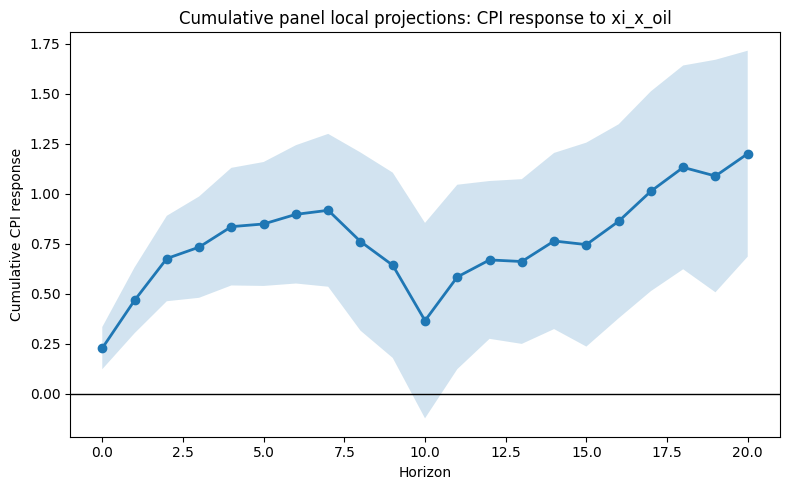

In [123]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, title="Cumulative panel local projections: CPI response to xi_x_oil", ax=ax)
ax.set_ylabel("Cumulative CPI response")
plt.tight_layout()
plt.show()


In [125]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                            OLS Regression Results                            
Dep. Variable:          cum_cpi_lead0   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     10.93
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.55e-06
Time:                        19:38:21   Log-Likelihood:                 11886.
No. Observations:                7252   AIC:                        -2.361e+04
Df Residuals:                    7170   BIC:                        -2.304e+04
Df Model:                          81                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0276    

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 81, but rank is 3
  warnings.warn('covariance of constraints does not have full '
